## Setup

### Imports

In [1]:
import os

import polars as pl
from scipy import stats
from matplotlib import pyplot as plt, rcParams
import synapseclient
from synapseclient.entity import File as sceFile

# set max font size 
rcParams["font.size"] = 7

### Constants

In [2]:
# Jupyter server should be running from src/python
# assumes auth_token.txt exists in src/python as described in setup instructions
AUTH_TOKEN = os.path.abspath("auth_token.txt")

# synapse IDs for the subset data
SUBSET_DATA_SYN_IDS = {
    "B_FLT3-ITD-WT.arrow": "syn74776638",
    "B_FLT3-ITD-WT.csv": "syn74776648",
    "B_FLT3-ITD-WT_mut-cols.txt": "syn74776635",
    "B_FLT3-ITD-WT_wt-cols.txt": "syn74776634",
    "B_FLT3-ITDxNPM1-WT.arrow": "syn74776644",
    "B_FLT3-ITDxNPM1-WT.csv": "syn74776636",
    "B_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776633",
    "B_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776632",
    "B_NPM1-WT.arrow": "syn74776645",
    "B_NPM1-WT.csv": "syn74776649",
    "B_NPM1-WT_mut-cols.txt": "syn74776642",
    "B_NPM1-WT_wt-cols.txt": "syn74776643",
    "W_FLT3-ITD-WT.arrow": "syn74776654",
    "W_FLT3-ITD-WT.csv": "syn74776655",
    "W_FLT3-ITD-WT_mut-cols.txt": "syn74776647",
    "W_FLT3-ITD-WT_wt-cols.txt": "syn74776646",
    "W_FLT3-ITDxNPM1-WT.arrow": "syn74776658",
    "W_FLT3-ITDxNPM1-WT.csv": "syn74776663",
    "W_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776650",
    "W_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776653",
    "W_NPM1-WT.arrow": "syn74776666",
    "W_NPM1-WT.csv": "syn74776667",
    "W_NPM1-WT_mut-cols.txt": "syn74776659",
    "W_NPM1-WT_wt-cols.txt": "syn74776660",
}

# Jupyter server should be running from src/python
CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_cache"
)
# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_figures",
    "volcano"
)
# directory for differentially expressed features
DIFFEX_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_cache",
    "diffex"
)

# define some colors for plotting
RED = "#AD3838"
BLUE = "#4040B1"
GREY = "#454545"

In [3]:
# ensure diffex and figure directories exist
os.makedirs(DIFFEX_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

### Synapse login

In [4]:
with open(AUTH_TOKEN, "r") as atf:
    SYN = synapseclient.login(authToken=atf.read())


UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.13.0) is available. Your version (4.11.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.13.0 release notes

https://python-docs.synapse.org/news/


Welcome, dylan.ross!



### Load Data

#### Utility Function: Load a mutant vs. WT comparison data subset, add ∆z and t-test p-value

In [19]:
def load_data_add_delta_z_and_ttest_p(
    subset_id: str,
    block: str
) :
    """ 
    loads a specified -omics block for a selected data subset, 
    adds ∆z and t-test p-value columns for the comparison of mutant vs. WT samples
    """
    print("=" * 20 + f"{subset_id=} {block=}" + "=" * 20)
    # load subset sample columns
    with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_wt-cols.txt"]).path, "r") as wtf:
        wt_cols = wtf.read().split("\n")
    with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_mut-cols.txt"]).path, "r") as mutf:
        mut_cols = mutf.read().split("\n")

    # load subset omics data
    omics_subset = pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}.arrow"]).path)

    # select out the block of interest, add columns, return
    return (
        omics_subset
        .filter(pl.col("Block") == block)
        .drop("Block")
        # for transcriptomics Log2 the values first
        .with_columns([
            (
                pl.col(col).log(2).fill_nan(None)
                if block == "Transcriptomics"
                else pl.col(col)
            )
            for col in wt_cols + mut_cols
        ])
        # add the ∆z and t-test p-value columns
        .with_columns(
            (
                pl.concat_list(wt_cols)
                .list.drop_nulls()
                .alias("wt")
            ),
            (
                pl.concat_list(mut_cols)
                .list.drop_nulls()
                .alias("mut")
            ),
        )
        .filter(
            (pl.col("wt").list.len() >= 5)
            & (pl.col("mut").list.len() >= 5)
        )
        .with_columns(
            (
                (
                    pl.col("mut").list.mean() - pl.col("wt").list.mean()
                )
                .alias("delta_z")
            ),
            (
                pl.struct("wt", "mut")
                .map_elements(
                    lambda x: stats.ttest_ind(
                        x["wt"], 
                        x["mut"], 
                        equal_var=False  # Welch's t-test
                    ).pvalue,  # type: ignore
                    return_dtype=pl.Float64
                )
                .alias("ttest_p")
            )
        )
        .drop(
            "wt",
            "mut"
        )
        # correct p-values for multiple comparisons
        # Benjamini-Hochberg
        .with_columns(
            pl.col("ttest_p")
            .map_batches(
                lambda s: pl.Series(stats.false_discovery_control(s.to_numpy()))
            )
            .alias("ttest_p_adj")
        )
    )

#### Load data for all comparisons

In [20]:
comps = {}
for subset_id in [
    "B_NPM1-WT", 
    "W_NPM1-WT", 
    # "B_FLT3-ITD-WT", 
    # "W_FLT3-ITD-WT", 
    # "B_FLT3-ITDxNPM1-WT", 
    # "W_FLT3-ITDxNPM1-WT"
]:
    for block in [
        #"Acetylomics",
        "Transcriptomics", 
        "Proteomics", 
        #"Phosphoproteomics",
        #"Lipidomics",
        "Metabolomics"
    ]:
        comps[(subset_id, block)] = load_data_add_delta_z_and_ttest_p(subset_id, block)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_74013/4016417925.py:11: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_wt-cols.txt"]).path, "r") as wtf:



====================subset_id='B_NPM1-WT' block='Transcriptomics'====================
[syn74776643:B_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/659/172720659/B_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_74013/4016417925.py:13: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_mut-cols.txt"]).path, "r") as mutf:



[syn74776642:B_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/658/172720658/B_NPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_74013/4016417925.py:17: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  omics_subset = pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}.arrow"]).path)



...

====================subset_id='W_NPM1-WT' block='Metabolomics'====================
[syn74776660:W_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/353/174033353/W_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_74013/4016417925.py:13: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_mut-cols.txt"]).path, "r") as mutf:



[syn74776659:W_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/684/172720684/W_NPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_74013/4016417925.py:17: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  omics_subset = pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


## Volcano Plots

### Utility Functions

#### Make the volcano plot

In [21]:
def volcano_plot(
    df: pl.DataFrame, 
    min_abs_delta_z: float, 
    max_p_value: float, 
    adjusted_p: bool,
    figname=None, 
    delta_z_range=None, 
    point_labels=None
) :
    # choose whether to select adjusted or unadjusted p-values
    p_col = "ttest_p_adj" if adjusted_p else "ttest_p"
    # helper: colors
    def _get_color(fold_change, p_value):
        if p_value <= max_p_value:
            if fold_change >= min_abs_delta_z:
                return RED
            if fold_change <= -min_abs_delta_z:
                return BLUE
        # default color
        return GREY
    fig, ax = plt.subplots(figsize=(4, 4))
    c = [
        _get_color(dz, pv)
        for dz, pv in df.select("delta_z", p_col).iter_rows()
    ]
    ax.scatter(df["delta_z"], df[p_col], c="#00000000", marker="o", edgecolors=c, s=6, linewidths=1.)
    # add point labels if provided
    if point_labels is not None:
        for lbl, dz, pv in point_labels.iter_rows():
            ax.plot(
                [dz, dz + 0.2 if dz > 0 else dz - 0.2],
                [pv, pv],
                #c=_get_color(dz, pv),
                c="k",
                lw=0.5, 
                marker=".",
                ms=2
            )
            ax.text(
                dz + 0.15 if dz > 0 else dz - 0.15,
                pv,
                lbl,
                color=_get_color(dz, pv),
                size=6, 
                va="center",
                ha="left" if dz > 0 else "right",
                #rotation=-15 if dz > 0 else 15,
                rotation_mode="anchor", 
                bbox=dict(
                    fc="w",
                    #ec=_get_color(dz, pv),
                    ec="k",
                    lw=0.5,
                    pad=0.3
                )
            )
    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.axhline(max_p_value, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(min_abs_delta_z, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(-min_abs_delta_z, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(0, lw=1., c="k", zorder=-1)
    for d in ["top", "left", "right"]:
        ax.spines[d].set_visible(False)
    if delta_z_range is not None:
        ax.set_xlim(delta_z_range)
    ax.set_xlabel("∆z")
    ax.set_ylabel("p-value")
    if figname is not None:
        plt.savefig(figname, bbox_inches="tight", transparent=True, dpi=400)
    plt.show()
    plt.close()

#### Make the plot plus select out the top/bottom features

In [30]:
def plot_volcano_and_select_top_features(
    df,
    dz, 
    pv,
    subset,
    block,
    adjusted_p=False,
    label_top_n=10,
    export_top_n=250
) : 
    # choose whether to select adjusted or unadjusted p-values
    p_col = "ttest_p_adj" if adjusted_p else "ttest_p"
    # select the top up/down features
    top_up = (
        df
        .filter(
            (pl.col(p_col) <= pv)
            & (pl.col("delta_z") >= dz)
        )
    )
    top_down = (
        df
        .filter(
            (pl.col(p_col) <= pv)
            & (pl.col("delta_z") <= -dz)
        )
    )
    # make the plot
    volcano_plot(
        df,
        dz,
        pv,
        adjusted_p=adjusted_p,
        figname=os.path.join(
            FIGURE_DIR, 
            f"{subset}_{block}.png"
        ),
        # add text labels for the top N up and down features 
        point_labels=(
            pl.concat([
                (
                    top_up
                    .select(
                        "Feature",
                        "delta_z",
                        p_col
                    )
                    .sort(p_col)
                    .head(label_top_n)
                ),
                (
                    top_down
                    .select(
                        "Feature",
                        "delta_z",
                        p_col
                    )
                    .sort(p_col)
                    .head(label_top_n)
                ),
            ])
        )
    )
    # write top up/down features to file
    for df, up_or_down in [(top_up, "up"), (top_down, "down")]:
        if len(df) > 0:
            # write just the identified features
            (
                df
                .sort(p_col)
                .head(export_top_n)
                .select("Feature")
                .write_csv(
                    os.path.join(
                        DIFFEX_DIR,
                        f"{subset}_{block}_{up_or_down}.txt"
                    ),
                    include_header=False
                )
            )
            # write the full table
            (
                df
                .sort(p_col)
                .head(export_top_n)
                .write_csv(
                    os.path.join(
                        DIFFEX_DIR,
                        f"{subset}_{block}_{up_or_down}.csv"
                    ),
                )
            )
    # return the selected top up/down features (+ their full data)
    return top_up, top_down

### Make the volcano plots for selected comparisons

============ B_NPM1-WT ============
Transcriptomics


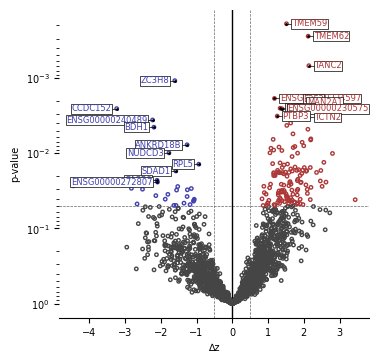

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CDC27""",null,null,null,-4.983609,1.086855,null,null,null,null,-0.237025,null,null,-0.945069,null,-1.186293,null,-1.002075,null,null,null,null,-0.392423,-7.345123,-0.122615,null,null,null,null,null,null,-3.29264,1.559729,-3.287512,null,null,null,…,0.572165,null,null,null,null,null,null,null,null,null,-1.433725,-1.024357,null,-9.194917,null,null,-3.059128,null,-2.271575,null,null,null,null,null,1.228057,null,null,0.669551,-0.811978,-0.234777,-1.414479,null,null,null,1.674934,0.041943,0.700838
"""LIG3""",null,null,0.114338,null,0.582469,null,null,null,null,null,null,-3.395277,null,null,null,null,null,-2.610279,-0.920055,null,null,null,null,2.207768,null,null,null,null,null,null,-1.767243,-0.676805,-1.128127,null,-3.634222,null,…,null,null,null,-2.171522,-1.402026,null,null,null,null,null,null,null,null,-7.257707,null,null,null,null,null,-1.995648,null,null,null,null,0.525918,null,null,0.023315,0.594845,1.604959,-0.878056,-1.707744,null,null,1.895852,0.019724,0.666531
"""GDE1""",null,-1.914013,null,null,0.777774,null,-1.587986,-1.783067,null,null,null,null,-2.817763,null,null,-3.01249,null,null,-1.705502,null,-0.674027,0.643854,-0.422039,null,null,-3.613201,null,null,null,null,null,null,null,-2.383703,null,null,…,null,null,null,null,null,null,null,null,null,null,-0.462742,-1.543678,-1.351386,-1.279827,null,null,null,null,null,null,null,null,null,null,2.282617,null,null,-0.631881,-0.88666,-1.110582,-0.367686,-0.351403,null,null,1.3935,0.042663,0.700838
"""SEC63""",null,null,null,null,null,null,-2.996126,null,null,null,null,-4.689176,-0.800516,null,-1.435461,-3.301502,-0.667413,-1.988568,-6.172364,null,-2.843367,null,0.665332,0.390723,null,0.147934,null,null,null,null,-2.323595,0.192938,-0.436086,null,null,null,…,1.472882,null,null,null,null,null,null,null,null,null,-4.6319,null,null,-4.713747,null,null,-0.942209,null,-1.238525,null,null,null,null,null,0.227955,null,null,0.376133,1.365217,-1.68026,null,-0.852574,null,null,1.582749,0.041027,0.700838
"""MAPK9""",null,null,0.127976,0.242545,null,null,null,-2.544239,null,null,null,null,-1.301242,-3.813306,-1.491443,null,0.687032,null,-0.226309,null,null,-0.28761,null,2.016903,null,null,null,null,null,null,null,-0.603632,0.696254,-2.003331,null,null,…,-0.493925,null,null,null,-0.428021,null,null,null,null,null,null,null,null,-1.942567,null,null,null,null,-1.189709,null,null,null,null,null,-0.524901,null,null,-0.684227,0.471592,0.085665,null,0.210821,null,null,0.832185,0.040329,0.700838
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000262877""",null,null,null,null,-0.49489,null,null,null,null,-2.135477,null,null,null,null,null,null,-3.527531,null,null,null,null,null,null,2.406102,null,null,null,null,null,null,-2.258328,null,null,null,null,null,…,null,null,null,-2.208094,null,null,null,null,null,null,null,null,-0.689695,null,null,null,null,-5.227414,-1.216993,null,n

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""BTBD7""",null,null,null,null,0.708481,null,null,null,null,null,null,null,0.055043,null,0.613079,null,0.56183,-2.382587,null,null,null,-0.847681,-2.66628,0.769085,null,-1.40092,null,null,null,null,null,0.536286,0.47955,null,null,null,…,2.315913,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-1.532502,null,null,-1.837637,-2.449743,null,-1.715352,-1.189428,null,null,-1.084342,0.043371,0.700838
"""MKS1""",null,null,-1.998724,-2.006044,1.766203,null,null,-2.71676,null,null,null,null,null,null,null,null,1.466592,null,null,null,null,-2.715983,null,0.494334,null,null,null,null,null,null,null,0.403372,-1.80316,-3.34077,null,null,…,null,null,null,null,null,null,null,null,-0.626781,null,null,-1.124366,null,null,null,null,null,null,-0.788859,0.824771,null,null,null,null,-1.730644,null,null,-1.266899,-1.829,-1.196547,-2.769596,null,null,null,-1.073512,0.042238,0.700838
"""NUDCD3""",null,null,0.260684,-1.870429,null,null,null,-0.978675,null,null,null,null,null,-1.067015,null,null,0.605565,null,-0.622599,null,null,-2.768894,null,1.832161,null,null,null,null,null,null,-2.938172,0.472578,-0.209651,-0.748723,-2.489024,null,…,null,null,null,-1.632098,-1.230835,null,null,null,0.567128,-4.708936,null,null,-0.409275,-1.819958,-0.820478,null,null,null,-0.094699,null,null,null,null,null,-4.085913,null,null,-2.534243,-2.955973,-2.967969,null,-1.356537,null,null,-1.771399,0.009865,0.659212
"""SF3A1""",null,null,-2.917725,null,-1.499484,null,null,null,null,null,null,1.304445,null,null,-2.592513,-1.600619,null,-0.862567,-2.187436,null,0.518103,null,0.166375,1.555168,null,0.986766,null,null,null,null,null,-1.568035,-0.31501,null,null,null,…,null,null,null,null,0.378904,null,null,null,null,null,-0.395275,null,null,-1.605352,null,null,null,null,null,null,null,null,null,null,-1.879093,null,null,-3.384647,-0.373303,null,-2.219302,-2.225194,null,null,-1.350159,0.046018,0.700838
"""COCH""",null,null,null,-1.954954,null,null,null,null,null,null,null,null,null,null,null,-0.36972,null,null,null,null,1.383338,null,null,0.326946,null,null,null,null,null,null,null,null,null,1.027012,null,null,…,2.299678,null,null,0.220998,1.08745,null,null,null,null,null,null,null,null,null,null,null,-0.98034,null,null,null,null,null,null,null,null,null,null,-0.256303,-1.741861,-0.54571,-2.885812,-1.263328,null,null,-1.557106,0.030861,0.700838
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ANKRD18B""",null,null,null,null,1.133237,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.857747,null,null,null,null,null,null,null,-0.133042,null,null,null,null,…,null,null,null,null,0.916923,null,null,null,null,null,null,null,null,2.17805,null,null,null,null,null,1.130877,null,null,null,null,-0.573006,null,null,0.13781,-0.922046,0.720359,-0.934876,-0.612021,null,null,-1.2

Proteomics


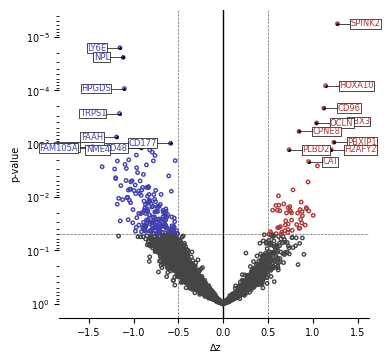

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALDH5A1""",-1.636885,-1.685539,-0.520642,-0.617834,null,null,null,null,null,null,-1.055934,0.295147,0.027569,0.497498,-0.471951,-0.357757,1.000938,-1.570717,0.914959,-0.403026,-0.267776,-0.934058,0.371211,0.972956,0.272329,-0.710898,-1.198361,0.223153,0.554236,0.073548,0.403825,1.186309,1.537115,1.625774,-0.063956,-0.265909,…,0.388004,-0.509326,2.077739,-0.489341,0.178698,-1.809202,-1.281635,-0.131939,-0.515776,-1.042803,0.079512,0.491136,-1.184134,-0.996292,-0.119448,-0.654951,-1.99034,-1.490546,0.998856,-2.43985,2.218574,-0.243718,-0.074936,0.70023,null,null,-0.069435,-0.540156,1.106514,1.976467,1.13383,-0.340791,1.488114,0.641198,0.694735,0.033394,0.999855
"""ARSA""",0.032506,0.781203,-0.745059,0.524555,null,null,null,null,null,null,0.567754,0.629336,0.062353,1.824556,-1.356563,-0.350023,-1.413901,-2.147134,-2.056281,-0.751503,-0.160018,-0.787671,1.210461,0.650755,0.759602,-0.14174,-0.083161,-1.017337,-0.202118,-0.529639,-1.385965,0.54382,-0.330215,-0.534694,0.032385,1.08745,…,-0.702438,-0.983544,0.43603,-1.117548,-2.274589,0.315208,-0.549148,0.589382,0.206795,0.747261,2.192836,-0.947574,-1.061391,0.690121,0.439093,-0.413738,0.472079,-0.808587,-1.034359,-0.139117,-0.194979,-0.672937,-0.011101,0.862634,null,null,-0.150123,0.553751,0.722815,0.220764,0.705577,1.503662,-0.247767,2.451226,0.762858,0.01973,0.999855
"""ATP8B4""",-0.82754,1.191326,-0.580083,-0.031687,null,null,null,null,null,null,-1.644191,-1.002383,-1.761926,-1.259805,-0.814558,-1.718367,-1.236569,-2.551685,-0.182197,-0.79815,1.03107,-1.070946,-0.310645,-0.272563,0.363773,0.53989,-0.998695,-0.930064,0.424567,-0.500973,-2.171013,0.952665,-0.151611,0.28517,-0.522613,1.499142,…,-2.797841,-1.12422,0.267145,0.11061,-1.140175,0.524447,0.066189,1.911065,0.223933,1.145049,0.606927,0.423116,1.101346,-0.350735,0.449943,0.872374,-0.457761,0.840368,-0.319348,0.141629,1.389604,-1.172613,0.127639,0.69232,null,null,0.279617,0.220311,0.262749,2.144563,1.239107,0.899336,-0.216925,1.107627,0.779578,0.007322,0.999855
"""BAHCC1""",-0.262754,-0.531515,null,0.440557,null,null,null,null,null,null,-1.128795,-1.201001,-2.830161,-1.628183,-1.622899,-1.62877,0.65424,-1.102399,-1.065292,-0.281965,-0.861467,-0.113136,-0.448313,0.17752,-0.529111,-0.102937,-1.560273,-1.013206,-0.106594,-0.207385,0.510036,1.328747,0.090256,-0.141892,0.0858,-2.099997,…,-0.165477,1.395153,1.267892,-0.313169,-0.958267,-0.137041,-0.450997,1.486779,1.285272,1.427608,0.818838,-0.190803,-0.071963,-0.373496,0.706285,1.797683,0.5578,1.378678,1.428042,-0.651474,0.470509,-1.518853,0.415498,null,null,null,-0.002395,0.163885,-0.200666,1.206952,0.522402,0.814861,1.216118,0.22385,0.552633,0.017652,0.999855
"""CAT""",-0.131117,0.131812,-0.973319,1.025617,null,null,null,null,null,null,-2.03785,-1.56646,-0.286758,-1.96826,-1.461018,-0.311323,-0.62125,-2.207095,-1.317326,0.769584,-0.439878,-1.447926,-0.820189,0.486788,-0.323553,-0.593299,-0.963967,-1.32495,0.267318,-0.721893,-0.83708,0.360413,-1.157816,2.009841,-1.3184

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABAT""",0.908251,1.18767,null,null,null,null,null,null,null,null,-1.536492,0.268764,-0.208044,1.560516,0.071137,-1.191214,-1.213074,-0.758474,-1.854291,-0.921256,1.028928,0.7821,-0.452642,-1.310555,0.218175,1.008145,-0.288884,0.141115,-1.032421,1.433645,0.17353,0.052259,-1.295965,3.699362,1.629181,-0.036783,…,0.36033,-0.067336,-1.516726,-0.458912,-0.155553,0.752693,-0.388651,-0.39409,0.694024,1.37565,-0.121348,-0.53583,1.120275,-0.58758,0.849934,-0.157022,-0.529227,-0.503317,0.588029,-0.98903,1.149821,-0.89727,-1.481292,null,null,null,-2.28603,-0.353005,-1.145287,0.079779,0.623472,0.051155,-1.232254,-0.125274,-0.745236,0.048531,0.999855
"""ABCB1""",-0.849585,0.015547,-0.395564,-0.898192,null,null,null,null,null,null,-1.679824,-0.251665,0.193138,0.915544,-0.325995,-1.877693,1.327621,-0.847815,1.530777,-0.304214,-0.370946,-0.109135,-0.789633,-0.247103,0.838534,-0.834072,-0.802034,0.756583,-1.008619,0.152007,0.052055,1.088148,1.975611,0.637032,0.377247,0.325839,…,-0.002425,1.142121,2.15251,-0.873016,1.682252,-0.403075,1.339757,-0.042884,0.085292,0.680726,-0.804107,1.711031,0.135673,-0.828339,0.670911,-0.076736,-0.512542,-0.119378,0.691289,-1.521658,1.756305,0.288305,null,-0.073318,null,null,-1.838972,-0.37782,-3.008472,-0.455561,-0.632119,-0.599097,-1.474883,-0.563545,-1.141471,0.006104,0.999855
"""ALOX12""",null,2.43145,null,null,null,null,null,null,null,null,0.432565,0.416826,0.30262,1.363449,0.23977,0.429405,0.034235,-1.463945,-0.58965,1.546862,0.117842,1.52446,1.416487,-0.925613,-0.874908,-0.784071,-0.74623,0.055452,-2.500077,-0.153398,0.222196,-0.913833,1.070116,0.11177,1.937788,0.171355,…,-0.012345,-1.181325,0.960681,0.156305,2.843787,0.472139,-1.264747,-0.184636,-0.100116,0.447489,0.278213,0.050608,-0.208966,-1.205727,0.435118,0.017107,-0.380598,0.077911,-0.79605,-0.460335,0.219084,-0.915812,null,-0.234821,null,null,-1.828784,-1.177702,-0.967485,-0.942971,-0.976509,-0.083319,-0.581378,0.066208,-0.855914,0.002498,0.648893
"""ALOX5""",0.761181,1.280557,-0.555611,1.421964,null,null,null,null,null,null,0.55159,0.462426,-0.656798,-0.464008,0.227109,-1.372554,-1.365004,0.402498,-2.203394,0.673513,1.30237,0.045252,0.79841,-2.028813,0.653021,0.427148,0.440023,-0.255696,-0.539198,0.850824,-0.42299,-0.484289,-1.18039,-0.021081,1.368059,1.870523,…,-1.520767,0.592453,-1.470272,0.242557,0.401072,1.172974,-0.261982,0.578108,1.520512,0.391173,-0.152606,-0.177279,0.62544,-1.401579,0.849598,1.056506,0.902332,1.419148,-1.288494,-0.379355,-1.146939,-0.833295,-0.499819,0.182759,null,null,-2.411655,0.295928,-1.592178,-0.064295,0.151558,0.245596,-2.190603,-0.822271,-0.773651,0.048666,0.999855
"""ANPEP""",0.630306,0.338042,0.997687,0.387941,null,null,null,null,null,null,-2.325397,-1.232857,-1.352032,-2.03428,0.65666,-2.200388,-0.608131,0.569372,-0.196663,-1.500468,-0.251232,0.220313,-1.039174,-1.525449,0.113158,0.33866,0.464311,0.869011,-0.327172,1.149979,-0.230176,-0.092191,0.011338,0.026219,2.225789,1.862844,…,-1.109672,-0.11734,-0

Metabolomics


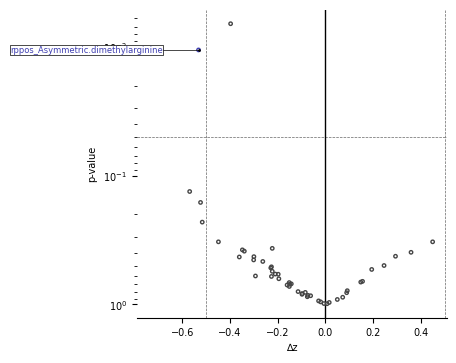

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_Asymmetric.dimethylargin…",-0.748212,null,2.329708,null,-1.070975,0.439137,-1.487901,-0.447447,-0.452977,0.566629,0.616603,0.768408,1.336114,-0.458948,-0.580273,0.26682,-0.597199,1.482295,0.493616,0.582129,-0.000548,-1.3204,1.816296,-0.766258,-0.321119,-0.822305,1.701702,-0.084615,-0.052229,0.302268,-0.235249,1.484934,-2.098618,1.931128,0.42029,-1.74585,…,1.179569,1.383112,0.994241,-0.136369,-0.141225,0.54685,-2.180024,0.089168,1.037896,-0.162531,0.721014,-0.367629,-0.188123,-2.198667,-1.645721,-0.253575,-1.098217,-0.225697,1.419581,-1.310104,0.31882,null,null,null,-0.825228,-0.821697,-0.607922,-0.030656,-0.54919,-0.642668,-1.070979,0.382523,-0.563206,0.087988,-0.532354,0.010581,0.259236


============ W_NPM1-WT ============
Transcriptomics


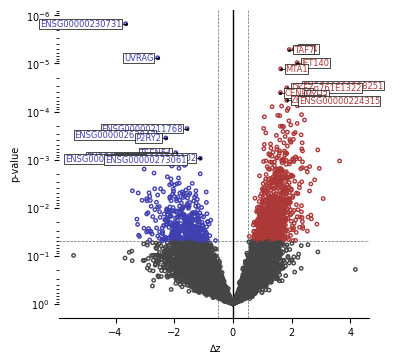

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""SKAP2""",null,-1.494468,null,null,null,null,null,-1.124965,-6.509192,-1.160604,null,null,null,null,null,null,null,null,null,-0.27177,-2.326448,null,null,null,null,-1.139239,-1.127441,null,null,1.225305,-2.333103,-1.022184,null,-0.3801,0.830167,-2.95865,…,null,-0.857181,null,null,null,null,null,null,null,null,null,0.362458,-0.211663,0.805375,null,0.28586,-0.115073,0.2156,-0.825992,0.467845,null,null,null,null,null,null,null,-0.543321,null,-1.090751,null,null,0.699683,0.100278,1.249421,0.001605,0.2315
"""MCUB""",null,-0.995855,null,null,null,null,0.579742,-2.45513,null,-0.032447,0.848511,-0.310749,1.195286,-0.882014,null,null,null,null,null,-5.188409,-0.613518,null,null,-5.383907,null,null,null,null,null,0.253802,null,0.546088,null,-0.412554,null,null,…,null,-4.012061,null,null,null,null,null,null,null,null,null,1.583966,null,null,null,null,null,null,null,null,null,null,null,null,0.210502,null,null,null,null,null,0.167056,-0.330467,0.628034,null,1.604618,0.006215,0.35951
"""LIG3""",null,null,null,null,null,null,-0.467216,null,null,null,null,null,null,null,null,null,null,null,null,0.445089,null,null,null,0.953047,0.238186,null,-0.073813,-0.192478,null,null,1.019808,null,-3.471442,null,-1.375621,-4.165804,…,-1.060633,-2.796991,null,null,null,null,null,null,null,null,null,null,-0.341037,-1.395835,-1.58823,-0.869649,-0.782601,0.951339,-0.862806,null,null,null,0.964358,null,null,null,-0.934227,0.352739,null,0.924375,null,0.419394,null,0.954788,0.885931,0.031532,0.544786
"""NFIX""",null,null,null,null,null,null,null,null,null,null,-0.664833,null,null,null,null,-2.383317,null,null,null,null,null,null,null,-2.295775,0.049123,null,null,null,null,null,1.188648,null,null,-1.427993,null,-0.737733,…,2.05116,null,null,null,null,null,null,null,null,null,null,null,0.187705,null,null,-0.165963,null,null,-0.153741,1.085872,null,null,-0.529354,null,null,null,2.250653,null,1.221249,null,-0.125268,null,null,null,1.790442,0.002776,0.272833
"""PKD1""",null,-5.121502,null,-0.647962,null,null,0.499743,null,null,null,null,0.348365,null,null,0.047851,-1.980368,null,null,null,null,null,null,null,1.346148,-1.443449,-0.907485,null,null,null,null,null,null,null,null,null,0.14857,…,0.962201,null,null,null,null,null,null,null,null,null,null,null,null,-0.403916,-0.104284,-0.676323,-1.592603,0.682808,1.321498,-0.483527,null,null,0.474338,null,null,null,null,0.120155,null,null,null,0.746808,null,0.608009,1.434773,0.002385,0.260779
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000273165""",null,null,null,null,null,null,null,-2.216349,-0.422134,-2.453995,null,null,null,null,null,null,null,null,null,null,null,null,null,-1.74959,null,null,null,null,null,null,-0.424078,null,null,null,null,-3.823391,…,0.787543,null,null,null,null,null,null,null,null,null,null,null,null,0.389693,null,null,null,null,-0.067416,null,null,null,-0.091345,null,null,null,null,1.615514,

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALS2""",null,null,null,-0.28937,null,null,2.053367,null,-0.387053,-0.979638,-1.283809,null,null,null,null,null,null,null,null,null,null,null,null,0.011209,0.529531,0.12043,null,null,null,null,null,null,null,null,null,-2.056824,…,null,null,null,null,null,null,null,null,null,null,null,null,-4.732982,null,null,null,-1.709266,-0.947851,null,-2.255472,null,null,-2.841416,null,null,null,null,-1.548649,null,null,null,-2.462375,null,-1.397065,-1.556761,0.015303,0.448882
"""ZMYND10""",null,-0.007082,null,null,null,null,0.098025,null,-1.437637,null,-1.09869,-1.603994,-1.437948,null,1.275097,null,null,null,null,null,null,null,null,0.238466,null,null,-0.901029,-2.300905,null,-4.202687,-0.04375,null,-2.225638,null,null,-0.529955,…,null,-0.886338,null,null,null,null,null,null,null,null,null,null,-1.51611,null,null,null,-3.379636,-2.05472,-1.046468,-1.270037,null,null,null,null,null,null,null,-0.288362,null,null,null,-2.106148,null,null,-1.03244,0.042825,0.585491
"""GCFC2""",null,null,null,-1.073729,null,null,null,null,-3.668383,null,0.273249,null,null,null,null,-0.525119,null,null,null,null,null,null,null,null,null,0.130754,-3.32579,null,null,null,-1.636488,0.745634,null,-0.578514,-0.336788,-0.021347,…,0.356105,-5.410097,null,null,null,null,null,null,null,null,null,null,null,null,null,-2.513805,-1.864365,null,null,-4.496782,null,null,-0.62131,null,null,null,-0.464788,null,-1.776006,null,null,null,null,null,-1.559203,0.048457,0.60595
"""DLEC1""",null,-2.014246,null,null,-3.990478,null,-0.889933,null,0.489984,null,null,null,null,null,-1.062387,null,null,null,null,null,null,null,null,null,null,null,-0.082913,-0.14024,null,null,null,null,null,-1.491084,0.357444,0.727023,…,null,2.235385,null,null,null,null,null,null,null,null,null,null,-2.1384,0.195237,null,null,-1.645699,null,null,-3.158391,null,null,null,null,null,null,-0.61297,null,null,null,null,-4.849525,-0.714854,-4.237901,-1.607005,0.046058,0.592862
"""PRDM11""",null,null,null,0.031424,null,null,0.120314,null,-0.952063,null,1.768514,null,null,null,null,null,null,null,null,null,null,null,null,0.820584,1.079472,0.162944,-2.467964,-1.059808,null,null,null,-1.26322,null,null,-4.084669,-1.41213,…,0.305295,null,null,null,null,null,null,null,null,null,null,null,-2.037557,null,null,-2.200807,-1.721412,-0.960937,-1.644712,-1.833241,null,null,-0.800649,null,null,null,-1.512487,-1.152949,null,null,null,-0.530132,null,-1.582398,-0.908887,0.004731,0.328171
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000272384""",null,null,null,0.268627,0.20276,null,0.049238,null,-3.815306,null,-4.617342,-0.183031,0.907627,null,null,-2.610891,null,null,null,-0.607235,-0.987237,null,null,0.318292,-1.790643,null,-0.090277,null,null,null,null,null,null,null,null,null,…,-1.937465,1.101775,null,null,null,null,null,null,null,null,null,null,-3.331855,null,null,-4.408883,null,null,null,-2.680829,null,null,0.621883,n

Proteomics


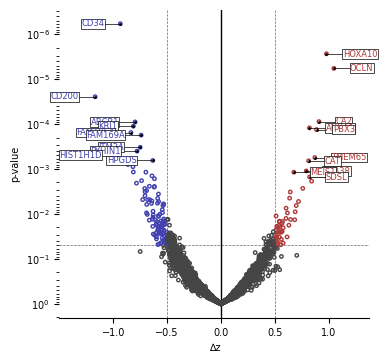

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ADAM17""",-0.665392,1.224915,0.905927,-1.289711,-0.580579,-1.034554,-2.76773,-1.485318,-1.072367,2.004734,-0.168518,0.591877,0.483407,0.142449,0.420409,-0.499061,-1.221819,0.104633,1.551389,0.449577,-0.318794,-0.935332,-0.045894,0.144436,-0.877667,0.157169,0.398032,0.955394,0.427359,1.748021,0.147122,-2.282285,-0.462436,0.529315,-1.909896,0.53454,…,-1.441297,-1.242197,0.300899,-0.964804,0.54245,-1.394184,0.318126,-0.605924,0.078689,-0.760506,0.995764,1.735029,1.58869,1.671418,0.35504,0.583932,-0.010711,-0.131985,1.173206,0.575301,0.570328,0.455523,-1.044564,1.567608,-2.289457,-1.322203,1.081462,2.033856,-0.182031,0.376654,1.060139,2.126676,0.947719,-0.17454,0.718819,0.005296,0.911136
"""ADGRE1""",0.212514,-0.319913,0.240618,-0.406769,-0.93078,1.384855,-1.227328,-0.572988,-0.539529,0.519696,-0.320891,1.213798,0.180349,-1.107668,-1.866009,0.321514,-1.676999,-0.433661,1.444539,0.071857,-0.520091,0.012926,-2.283331,-1.335582,-0.578396,-0.700866,-0.219502,-0.006356,1.262056,-0.043022,0.405166,-1.135821,1.684745,-0.386502,-1.421445,-0.298842,…,-0.250656,0.073549,0.106304,-1.176539,-0.733248,0.112746,-0.523765,1.13719,0.223726,-0.782232,-0.373458,2.419594,0.548559,1.014661,-0.779293,0.887638,0.640656,-0.128819,0.147803,1.665655,-0.371706,1.31336,-1.076443,1.4963,-1.221205,-1.945514,0.734654,1.74902,0.08319,1.169133,1.318719,1.552357,2.043523,0.26312,0.687889,0.008997,0.999894
"""ANXA1""",-0.06518,-0.344929,0.957281,-2.142164,-0.211283,-0.536254,-2.376397,-0.702281,0.122102,0.954419,-1.233053,0.106148,-0.827532,-0.636065,0.042115,-0.512114,-1.188125,0.399051,0.828426,0.848993,-0.36088,-1.109749,0.343915,0.665714,-1.112489,-0.025598,-0.298367,-0.575521,1.024904,1.618668,0.839303,-2.293753,0.109387,1.065981,0.135978,1.193013,…,-0.730903,0.538181,0.601621,-2.382338,0.268843,-0.854527,0.160395,1.126109,0.391571,-0.175666,1.148714,1.281232,1.643098,0.516196,0.731983,1.327557,-0.074011,0.533037,1.056968,0.417164,0.378209,0.885557,-0.491742,0.787898,-1.279781,-1.122118,1.532681,1.813539,0.547609,1.398247,0.904882,1.393722,0.342455,0.003081,0.819942,0.000122,0.119046
"""ATP8B4""",-0.790298,2.088681,1.138581,-1.050874,1.365711,-0.27807,-2.467097,-1.317747,-0.09235,1.20482,-0.151848,-0.584371,-0.290392,-0.534578,1.911103,-0.463074,-0.158104,-1.475402,1.286741,0.646915,-0.366161,-0.241496,-0.618284,-0.546736,-1.224743,0.203028,0.780454,1.222834,1.220742,0.385972,0.623506,-2.171634,-0.235286,0.606868,-0.735349,-0.473925,…,-1.920242,-0.072982,-0.03202,-2.707013,0.893792,-0.467925,0.525011,0.229356,-0.271199,0.2122,-0.455179,2.188729,1.523544,1.474958,0.586817,2.157953,0.635725,-0.040278,0.511358,0.17133,0.289802,0.413079,-1.228806,1.150197,-1.261788,-1.230867,-0.129824,1.543692,-0.03137,1.179078,1.097089,0.178071,0.294264,-0.823517,0.5332,0.024717,0.999894
"""BEND5""",0.334537,-1.034769,-0.090292,-1.132711,-2.070787,null,-0.927829,0.099146,0.425883,-2.405819,-1.174425,0.50789,-1.917936,-0.460152,null,-0.176536,-0.354228,0.765829,0.613442,-0.538298,-

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCB1""",1.242199,-0.276604,0.014818,0.496685,-0.197465,1.229728,-1.661001,-1.696032,-0.458131,0.990262,1.8688,0.032781,-0.069056,-0.205078,-0.871001,1.724275,null,-0.186125,0.054304,-0.090675,0.05239,-0.15966,1.065066,-1.403031,0.561542,1.9261,-0.607947,0.890605,-0.532857,0.112266,0.578762,-1.51821,-0.845604,0.709689,-0.413098,1.391581,…,-1.284009,-0.612396,2.190476,-1.049977,-0.449838,-1.131008,0.064151,-0.404539,-0.145416,-0.240245,-1.085909,0.517183,0.026922,-0.210375,-0.710001,-1.000752,-0.71029,-0.745064,-0.313236,-0.435649,-1.365115,-1.32168,-1.806276,0.404541,-2.332196,-1.310893,null,-0.365148,0.285544,-0.301275,0.44957,-0.79798,-0.93005,-0.433353,-0.796633,0.00009,0.119046
"""ABI3""",0.044575,0.064387,0.760996,-0.237147,1.021735,1.004611,-0.155803,-0.987911,-1.666024,1.978646,-0.83516,0.668123,1.569287,0.0809,-0.2341,0.425855,-0.973206,0.564091,1.931837,0.700082,0.053814,-0.658503,0.569209,-0.776581,-0.262192,-0.188789,0.241942,0.204719,1.839326,0.766904,-0.201972,-1.849395,-0.123897,1.716547,-1.557149,0.219637,…,-1.98506,-1.04744,0.174295,0.432228,0.046612,-1.182127,1.864389,0.114563,-0.188096,1.123874,-1.751048,0.811165,0.625739,1.533878,-1.095258,0.110025,-1.105796,-1.171008,-0.660578,1.009656,-0.402801,-0.839687,-1.559993,-0.081121,-1.674104,-1.291952,-1.038478,-0.236912,0.272755,0.053614,1.425902,-1.580911,-0.644449,-1.473478,-0.563055,0.018411,0.999894
"""ACY3""",-0.677411,0.014411,0.369566,-1.10196,-0.433711,2.107696,-1.313932,-1.39325,-0.687844,1.371531,2.746766,1.634147,0.341104,-0.15323,-0.724472,-0.305954,-1.37972,0.001026,-0.28601,-0.196973,-0.387401,1.57594,0.823634,-1.180652,-0.083727,2.234612,-0.138471,-0.180916,0.078604,0.317764,1.834311,0.687702,-1.137373,1.327892,-1.705709,0.378834,…,-0.674347,-0.511358,0.507078,-0.617943,-0.905869,-0.966837,null,-0.055469,0.533155,1.553371,-0.824482,0.085516,0.909598,0.118007,0.881792,-0.732288,-0.601376,-1.192405,-0.150394,0.584805,-1.54045,-1.135597,-1.183214,0.39261,-1.653545,-1.765982,-0.363578,-0.245775,-0.088371,-0.541955,0.452196,-1.20164,-0.741817,-1.285464,-0.619796,0.00254,0.639757
"""AGTRAP""",-0.85065,0.265313,1.802697,-0.836056,2.146507,-0.150034,-2.049022,0.248781,1.265485,0.594802,1.044328,0.275145,0.19429,0.40164,-0.061575,-1.192054,0.531611,-0.442434,1.060728,1.778767,0.743067,-0.840942,0.065615,-0.640481,-0.456719,-0.153834,0.28908,0.384794,1.690671,-0.149588,0.457438,-1.123674,0.260161,0.805248,-1.886129,0.876606,…,-1.822711,1.043288,1.060545,-1.35208,-0.150696,1.361417,-0.939787,1.729951,0.724083,1.026792,-0.901615,0.913211,0.355084,0.674144,-0.72813,0.233291,-1.351146,-1.429025,-0.351273,-0.045862,-1.084117,-1.007195,-1.537767,0.370742,-2.735067,-0.738135,-0.114935,-0.029649,-0.251517,0.528471,0.23748,-0.600471,-0.49552,-1.17358,-0.589089,0.005799,0.956623
"""AIF1L""",0.435112,0.244671,1.007247,-0.519597,0.158912,1.189721,0.530207,-1.404789,-0.475074,0.532776,0.54368,0.632032,0.282405,1.160556,-0.827461,0.768149,-1.192135,1.112,0.284147,0.833389,-

Metabolomics


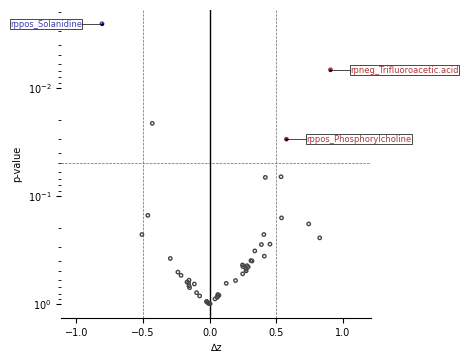

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_Phosphorylcholine""",0.072128,-3.055312,-0.72547,-1.094427,-0.026359,-1.240776,0.430148,0.261736,-0.842994,-1.148287,1.429513,-1.874284,-0.029841,1.297002,0.229325,1.52232,0.264086,-0.298835,-0.404654,-0.172687,-0.467747,null,0.75994,-0.774641,0.176643,-0.155624,-0.458423,0.128544,null,null,null,0.045892,null,null,null,null,…,null,-1.461949,null,null,null,null,null,null,null,null,0.990329,1.269444,0.049673,0.086431,0.403452,0.159466,0.460879,-0.623836,1.248747,0.579182,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.575151,0.030001,0.367515
"""rpneg_Trifluoroacetic.acid""",-0.645465,-1.850586,-0.508841,-1.646591,-0.534271,-0.378969,0.497714,1.494652,-0.403837,-0.598273,1.798179,0.090629,-0.738507,-0.676306,-0.437854,0.227053,0.42522,0.828664,-2.248674,-0.662264,-0.415972,null,1.7346,0.875863,0.61742,-0.760872,0.129687,-1.415675,null,null,null,0.42451,null,null,null,null,…,null,-1.464462,null,null,null,null,null,null,null,null,1.7346,0.937479,0.7277,0.323701,1.207484,0.082876,0.666556,-0.721928,1.958211,0.363959,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.90564,0.006847,0.167748


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_Solanidine""",1.544853,0.472242,-0.703594,-1.324906,0.009148,0.189381,-0.793779,-1.168735,1.444071,-0.644689,-0.644579,-1.167288,1.775658,0.432514,-0.872972,-0.714825,-0.974972,-1.231009,0.493893,-0.889953,1.728559,null,0.590767,1.500949,2.165771,-0.828569,0.151359,1.713837,null,null,null,0.643716,null,null,null,null,…,null,0.572608,null,null,null,null,null,null,null,null,-0.945688,-0.768177,-1.178214,0.425275,-1.089149,-1.130848,-0.19713,0.124524,-0.703007,-1.03452,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.808155,0.00257,0.12595


============ B_FLT3-ITD-WT ============
============ W_FLT3-ITD-WT ============
============ B_FLT3-ITDxNPM1-WT ============
============ W_FLT3-ITDxNPM1-WT ============


In [31]:
# key: (subset_id, block)
# value: {"up": top_n_up_df, "down": top_n_down_df}
top_up_and_down = {}

for subset_id in [
    "B_NPM1-WT", 
    "W_NPM1-WT", 
    "B_FLT3-ITD-WT", 
    "W_FLT3-ITD-WT", 
    "B_FLT3-ITDxNPM1-WT", 
    "W_FLT3-ITDxNPM1-WT"
]:
    print("============", subset_id, "============")
    for block in [
        "Transcriptomics", 
        "Proteomics", 
        "Phosphoproteomics",
        "Acetylomics",
        "Lipidomics",
        "Metabolomics"
    ]:
        if (df := comps.get((subset_id, block))) is not None:
            print(block)
            top_up, top_down = plot_volcano_and_select_top_features(
                df,
                0.5,   # effect size
                0.05,  # adjusted ttest p value
                subset_id,
                block
            )
            display(top_up)
            display(top_down)
            top_up_and_down[(subset_id, block)] = {"up": top_up, "down": top_down}

### Compare counts of selected features between black and white patients

#### NPM1

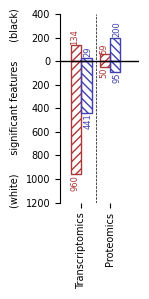

In [40]:
# bar data
x = list(range(1, 3)) * 2
all_up = [
    # black patients
    len(top_up_and_down[("B_NPM1-WT", "Transcriptomics")]["up"]), 
    len(top_up_and_down[("B_NPM1-WT", "Proteomics")]["up"]),
    #len(top_up_and_down[("B_NPM1-WT", "Lipidomics")]["up"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_NPM1-WT", "Transcriptomics")]["up"]), 
    -len(top_up_and_down[("W_NPM1-WT", "Proteomics")]["up"]),
    #-len(top_up_and_down[("W_NPM1-WT", "Lipidomics")]["up"]),
]
all_down = [
    # black patients
    len(top_up_and_down[("B_NPM1-WT", "Transcriptomics")]["down"]), 
    len(top_up_and_down[("B_NPM1-WT", "Proteomics")]["down"]),
    #len(top_up_and_down[("B_NPM1-WT", "Lipidomics")]["down"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_NPM1-WT", "Transcriptomics")]["down"]), 
    -len(top_up_and_down[("W_NPM1-WT", "Proteomics")]["down"]),
    #-len(top_up_and_down[("W_NPM1-WT", "Lipidomics")]["down"]),
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(1.5, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5,]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 3))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        #"Lipidomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])
ax.set_xlim([0.25, 3.])
plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_NPM1-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.tight_layout()
plt.show()
plt.close()


### Combine top up- and down- features into a big table

In [14]:
# columns:
# population, mutation_comparison, omics_type, feature, delta_z, ttest_p, ttest_p_adj

In [26]:
top_features = pl.concat([
    (
        top_up_and_down[(subset_id, omics_type)][direction]
        .select(
            "Feature",
            "delta_z",
            "ttest_p",
            #"ttest_p_adj"
        )
        .with_columns(
            pl.lit({"B": "Black", "W": "White"}[subset_id.split("_", maxsplit=1)[0]]).alias("population"),
            pl.lit(subset_id.split("_", maxsplit=1)[1]).alias("mutation_comparison"),
            pl.lit(omics_type).alias("omics_type")
        )
    )
    for (subset_id, omics_type) in top_up_and_down.keys()
    for direction in ["up", "down"]
])
top_features

Feature,delta_z,ttest_p,population,mutation_comparison,omics_type
str,f64,f64,str,str,str
"""CDC27""",1.674934,0.041943,"""Black""","""NPM1-WT""","""Transcriptomics"""
"""LIG3""",1.895852,0.019724,"""Black""","""NPM1-WT""","""Transcriptomics"""
"""GDE1""",1.3935,0.042663,"""Black""","""NPM1-WT""","""Transcriptomics"""
"""SEC63""",1.582749,0.041027,"""Black""","""NPM1-WT""","""Transcriptomics"""
"""MAPK9""",0.832185,0.040329,"""Black""","""NPM1-WT""","""Transcriptomics"""
…,…,…,…,…,…
"""VSTM1""",-0.689064,0.006173,"""White""","""NPM1-WT""","""Proteomics"""
"""ZNF615""",-0.615805,0.029671,"""White""","""NPM1-WT""","""Proteomics"""
"""rppos_Phosphorylcholine""",0.575151,0.030001,"""White""","""NPM1-WT""","""Metabolomics"""


In [27]:
top_features.write_ipc(os.path.join(DIFFEX_DIR, "all_top_features.arrow"))
top_features.write_csv(os.path.join(DIFFEX_DIR, "all_top_features.csv"))

In [17]:
#SYN.store(sceFile(path=os.path.join(DIFFEX_DIR, "all_top_features.arrow"), id="syn74782709"))
#SYN.store(sceFile(path=os.path.join(DIFFEX_DIR, "all_top_features.csv"), id="syn74782710"))